# Regressão logística - Classificação

O estudo de caso usa o **AI4I 2020 Predictive Maintenance Dataset**, da UCI Machine Learning Repository, para classificar falhas de máquina a partir de variáveis de processo.

Fonte dos dados: https://archive.ics.uci.edu/dataset/601


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

FIG_DIR = Path("figuras")
DATA_DIR = Path("data")
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
DATA_PATH = DATA_DIR / "ai4i2020_predictive_maintenance.csv"


## Problema e modelo

Na aula, o problema guia é manutenção preditiva:

$$
P(\text{falha}=1 \mid \text{medições})
$$

Temos exemplos rotulados

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}, \qquad x_i \in \mathbb{R}^p,\quad y_i \in \{0,1\}.
$$

Um modelo linear simples produz um escore

$$
z_i=\beta_0+\beta^T x_i,
$$

mas esse escore pode assumir qualquer valor real. Para obter uma probabilidade, comprimimos o escore com a função logística:

$$
\hat p(y=1\mid x)=\sigma(\beta_0+\beta^T x), \qquad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Depois de estimar a probabilidade, escolhemos um limiar $\tau$:

$$
\hat y =
\begin{cases}
1, & \hat p \geq \tau,\\
0, & \hat p < \tau.
\end{cases}
$$

O limiar é uma decisão de risco e custo: $\tau$ baixo aumenta alarmes de falha e recall; $\tau$ alto reduz alarmes e tende a aumentar precisão.


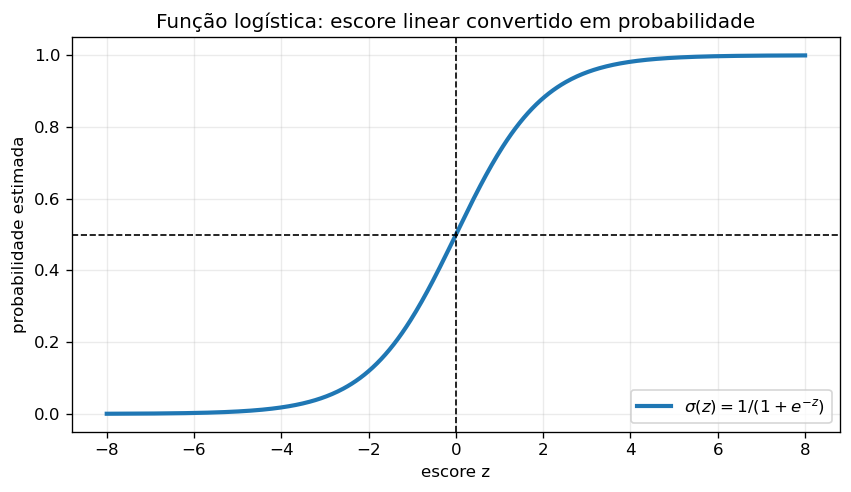

In [2]:
z = np.linspace(-8, 8, 500)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(z, sigma, color="#1f77b4", linewidth=2.5, label=r"$\sigma(z)=1/(1+e^{-z})$")
ax.axhline(0.5, color="black", linewidth=1, linestyle="--")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("escore z")
ax.set_ylabel("probabilidade estimada")
ax.set_title("Função logística: escore linear convertido em probabilidade")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "logreg_sigmoide.png", bbox_inches="tight")
plt.show()

## Logit: onde a parte linear aparece

A regressão logística é linear no logaritmo das chances:

$$
\text{logit}(p)
=
\log\left(\frac{p}{1-p}\right)
=
\beta_0+\beta^T x.
$$

Portanto, o modelo não é linear diretamente na probabilidade; ele é linear no **logit**.


## Treinamento, perda e regularização

Para treinar o modelo, escolhemos os parâmetros

$$
\beta_0,\beta_1,\ldots,\beta_p
$$

que minimizam a perda logarítmica:

$$
J(\beta)=
-\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i\log(\hat p_i)
+(1-y_i)\log(1-\hat p_i)
\right].
$$

Se $y_i=1$, a perda individual é $J_i=-\log(\hat p_i)$.  
Se $y_i=0$, a perda individual é $J_i=-\log(1-\hat p_i)$.

Com penalização L2:

$$
J_{\text{reg}}(\beta)=J(\beta)+\lambda\sum_{j=1}^{p}\beta_j^2.
$$

A regularização evita coeficientes exagerados e ajuda a reduzir sobreajuste. Como as variáveis têm unidades diferentes, a padronização é parte importante do pipeline.


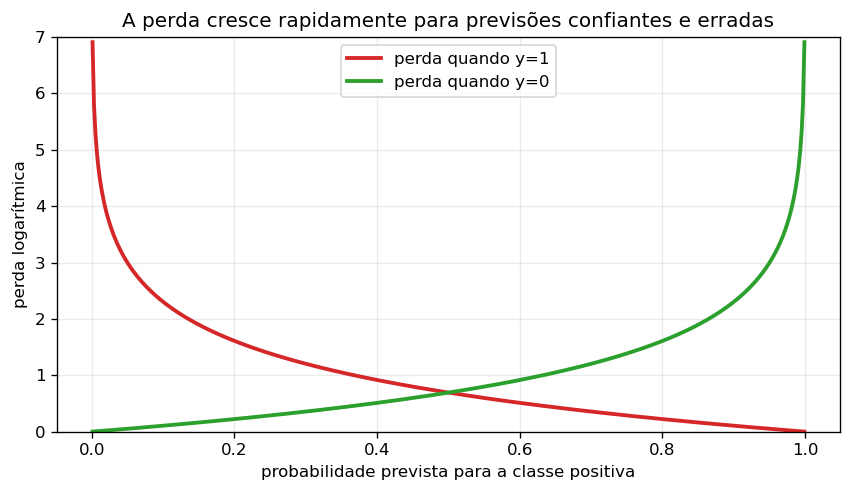

In [3]:
p = np.linspace(0.001, 0.999, 500)
loss_y1 = -np.log(p)
loss_y0 = -np.log(1 - p)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(p, loss_y1, label="perda quando y=1", color="#d62728", linewidth=2.3)
ax.plot(p, loss_y0, label="perda quando y=0", color="#2ca02c", linewidth=2.3)
ax.set_ylim(0, 7)
ax.set_xlabel("probabilidade prevista para a classe positiva")
ax.set_ylabel("perda logarítmica")
ax.set_title("A perda cresce rapidamente para previsões confiantes e erradas")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "logreg_logloss.png", bbox_inches="tight")
plt.show()

## Pipeline de treino

A forma compacta do pipeline é:

```python
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C=1.0,
        max_iter=2000,
        random_state=42)),
])
```

No estudo de caso abaixo, usamos apenas as variáveis numéricas e padronizamos todas elas com `StandardScaler`. Também usamos `class_weight="balanced"` porque as falhas são raras.


## Dados reais: AI4I 2020

O conjunto **AI4I 2020 Predictive Maintenance Dataset** contém 10.000 amostras de operação de uma máquina industrial.

- alvo: `Machine failure`;
- 339 falhas;
- falhas são raras;
- variáveis usadas no modelo: temperatura do ar, temperatura de processo, velocidade de rotação, torque e desgaste da ferramenta.

O arquivo CSV local é usado quando já existe.


In [5]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(10000, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [6]:
target = "Machine failure"
X = df.drop(columns=[target])
y = df[target].astype(int)

print(df.info())
print("\nDistribuição das classes:")
print(y.value_counts().rename(index={0: "sem falha", 1: "falha"}))
print("\nTaxa de falha: {:.2f}%".format(100 * y.mean()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB
None

Distribuição das classes:
Machine failure
sem falha    9661
falha         339
Name: count, dtype: int64

Taxa de falha: 3.39%


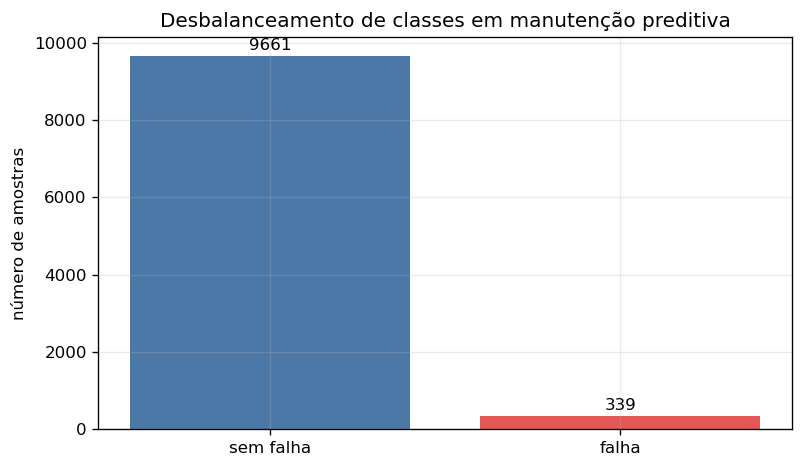

In [7]:
class_counts = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.8, 4.0))
bars = ax.bar(["sem falha", "falha"], class_counts.values, color=["#4c78a8", "#e45756"])
ax.set_ylabel("número de amostras")
ax.set_title("Desbalanceamento de classes em manutenção preditiva")
for bar, value in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 80, str(value), ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIG_DIR / "logreg_balanceamento.png", bbox_inches="tight")
plt.show()

## Treino com `scikit-learn`

A divisão treino/teste é estratificada para manter aproximadamente a proporção de falhas nas duas partes. O modelo usa somente atributos numéricos, estima probabilidades com `predict_proba` e obtém a classe comparando a probabilidade com o limiar $\tau=0{,}5$.


In [13]:
numeric_features = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear"]
X_model = X[numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.25, random_state=42, stratify=y
)

model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0, random_state=42)),
    ]
)

model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
}
pd.Series(metrics).to_frame("valor")


,valor
accuracy,0.820000
precision,0.135729
recall,0.800000
f1,0.232082


## Resultado no conjunto de teste

Com o pipeline usando apenas variáveis numéricas, os números são:

- acurácia: 0,820;
- precisão: 0,136;
- recall: 0,800;
- $F_1$: 0,232.

A leitura importante é que a acurácia geral parece alta, mas a precisão baixa mostra muitos falsos alarmes. O recall elevado indica que o modelo identifica boa parte das falhas reais.


In [14]:
print(classification_report(y_test, y_pred, target_names=["sem falha", "falha"], digits=3))

              precision    recall  f1-score   support

   sem falha      0.991     0.821     0.898      2415
       falha      0.136     0.800     0.232        85

    accuracy                          0.820      2500
   macro avg      0.564     0.810     0.565      2500
weighted avg      0.962     0.820     0.875      2500



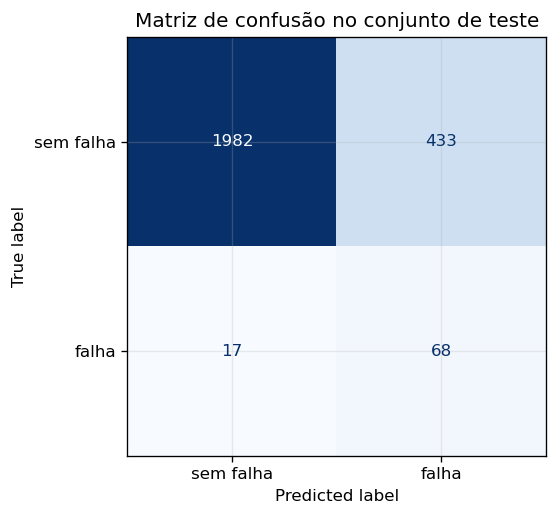

In [15]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.4, 4.4))
disp = ConfusionMatrixDisplay(cm, display_labels=["sem falha", "falha"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriz de confusão no conjunto de teste")
fig.tight_layout()
fig.savefig(FIG_DIR / "logreg_matriz_confusao.png", bbox_inches="tight")
plt.show()

## Escolha do limiar por custo

Se uma falha não detectada custa mais que uma inspeção extra, escolhemos o limiar $\tau$ minimizando:

$$
C(\tau)=c_{FP}FP(\tau)+c_{FN}FN(\tau).
$$

Uso correto dos dados:

- treino: ajusta os parâmetros do modelo;
- validação: escolhe o limiar $\tau$ que minimiza o custo;
- teste: avalia o desempenho final com $\tau$ já fixado.

A curva de custo abaixo é calculada na validação.


limiar        0.430000
FP          370.000000
FN            7.000000
custo       545.000000
precisao      0.131455
recall        0.888889
Name: 76, dtype: float64


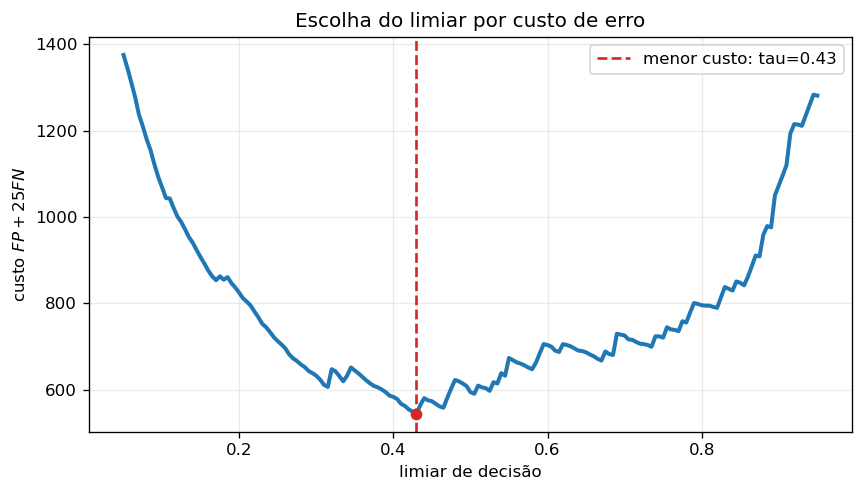

In [17]:
# Custos relativos do exemplo didático: falso negativo custa 25 vezes um falso positivo.
c_fp = 1
c_fn = 25

# O limiar deve ser escolhido na validação, não no teste.
# Por isso, separamos uma parte do conjunto de treino para validar os limiares.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# Este modelo é treinado apenas em X_fit; o conjunto de teste permanece reservado.
threshold_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0, random_state=42)),
    ]
)
threshold_model.fit(X_fit, y_fit)
y_val_proba = threshold_model.predict_proba(X_val)[:, 1]

# Calcula FP, FN e custo para cada limiar usando somente a validação.
threshold_grid = np.linspace(0.05, 0.95, 181)
cost_rows = []
for th in threshold_grid:
    pred = (y_val_proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    cost_rows.append({
        "limiar": th,
        "FP": fp,
        "FN": fn,
        "custo": c_fp * fp + c_fn * fn,
        "precisao": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
    })

cost_df = pd.DataFrame(cost_rows)
# Limiar que minimiza o custo na validação.
best_cost = cost_df.loc[cost_df["custo"].idxmin()]
print(best_cost)

fig, ax = plt.subplots(figsize=(7.3, 4.2))
ax.plot(cost_df["limiar"], cost_df["custo"], color="#1f77b4", linewidth=2.4)
ax.axvline(best_cost["limiar"], color="#d62728", linestyle="--", linewidth=1.6,
           label=f"menor custo: tau={best_cost['limiar']:.2f}")
ax.scatter([best_cost["limiar"]], [best_cost["custo"]], color="#d62728", zorder=3)
ax.set_xlabel("limiar de decisão")
ax.set_ylabel(r"custo $FP + 25 FN$")
ax.set_title("Escolha do limiar por custo de erro")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "logreg_custo_limiar.png", bbox_inches="tight")
plt.show()

## Comparação com KNN

Para comparar com a aula anterior, usamos as mesmas variáveis numéricas, a mesma padronização, a mesma divisão treino/teste e $\tau=0{,}5$.

O KNN com $k=15$ foi mais seletivo: gerou poucos alarmes falsos, mas perdeu muitas falhas. A regressão logística foi mais conservadora para segurança, com recall maior.


In [11]:
knn_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=15, weights="distance")),
    ]
)

models = {
    "Reg. logística": model,
    "KNN (k=15)": knn_model,
}

comparison_rows = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    comparison_rows.append({
        "Modelo": name,
        "Recall": recall_score(y_test, pred),
        "Precisão": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Modelo")
comparison_df

,Recall,Precisão,F1
Modelo,,,
Reg. logística,0.800000,0.135729,0.232082
KNN (k=15),0.235294,0.869565,0.370370


## Resumo final

1. A regressão logística estima $P(y=1\mid x)$.
2. A sigmoide transforma escore linear em probabilidade.
3. O treinamento minimiza perda logarítmica regularizada.
4. A probabilidade vira decisão por um limiar $\tau$.
5. Em engenharia, $\tau$ deve ser escolhido com base no custo dos erros.

## Referências

- GRUS, Joel. *Data Science do Zero: Noções Fundamentais com Python*. 2ª ed. Rio de Janeiro: Alta Books, 2020.
- UCI Machine Learning Repository: AI4I 2020 Predictive Maintenance Dataset. https://archive.ics.uci.edu/dataset/601
- Pedregosa et al. *Scikit-learn: Machine Learning in Python*. JMLR, 2011.
